# X-ray luminosity interpolator

This notebook creates an interpolator function for the cooling curves obtained from magneto-thermal simulations for different values of the initial magnetic field.
The interpolator serves as a function that, given the age and the initial magnetic field of a neutron star, gives as output the X-ray thermal luminosity at that age. 
Since we have only a small set of magneto-thermal cooling curves, we need to interpolate between them to obtain the X-ray luminosity for any given age and initial magnetic field.

In [1]:
# import libraries
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import scipy.integrate as integrate
from scipy import interpolate
from scipy.interpolate import UnivariateSpline
import pickle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

import pypopsyn.simulator.basics.constants as const
from pypopsyn.simulator.config_simulator import cfg
import utilities.plot_settings

## Load the results from the magneto-thermal simulations

In [2]:
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e12_Btor1e13.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e13_Btor1e14.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e14_Btor1e15.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip1e15_Btor1e16.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/cool_curve_CC_Bdip5e15_Btor1e16.csv"
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e12_H.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e13_H.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e14_H.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_1e15_H.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/50-50_5e15_H.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_light":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e12_L.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e13_L.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e14_L.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_1e15_L.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/50-50_5e15_L.csv"
elif cfg["magneto-thermal_model"] == "BKS24_multi_heavy":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e12_H.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e13_H.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e14_H.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_1e15_H.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/multi_5e15_H.csv"    
elif cfg["magneto-thermal_model"] == "BKS24_multi_light":
    simB12_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e12_L.csv"
    simB13_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e13_L.csv"
    simB14_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e14_L.csv"
    simB15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_1e15_L.csv"
    simB5e15_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/multi_5e15_L.csv"    

In [3]:
df_B12 = pd.read_csv(
    simB12_path,
    delimiter=",",
    header=[0],
)
df_B12.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+12,1.245832e+36,0.001000,1.016742e-12,1.047198,0.001000,2.904977e-13,0.001000,6.488486e-13,3.000000e+14,50,5.200000e+13
1,1.000,9.994200e+11,5.882812e+34,0.001028,9.842215e-13,1.040230,0.001008,2.878329e-13,0.001018,6.365612e-13,3.000000e+14,50,5.200000e+13
2,2.012,9.993600e+11,5.611416e+34,0.001059,9.518164e-13,1.032775,0.001017,2.852106e-13,0.001038,6.241501e-13,3.000000e+14,50,5.200000e+13
3,3.030,9.993000e+11,5.511288e+34,0.001089,9.220568e-13,1.025638,0.001026,2.826437e-13,0.001058,6.123668e-13,3.000000e+14,50,5.200000e+13
4,4.067,9.992390e+11,5.434458e+34,0.001119,8.942632e-13,1.018705,0.001036,2.800978e-13,0.001078,6.010188e-13,3.000000e+14,50,5.200000e+13


In [4]:
df_B13 = pd.read_csv(
    simB13_path,
    delimiter=",",
    header=[0],
)
df_B13.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+13,9.860081e+35,0.001000,1.016741e-10,1.047198,0.001000,2.904973e-11,0.001000,6.488478e-11,3.000000e+14,50,5.200000e+13
1,1.000,9.994140e+12,5.712735e+34,0.002502,3.461317e-11,0.777622,0.001628,1.782117e-11,0.002166,2.992210e-11,3.000000e+14,50,5.200000e+13
2,2.012,9.993432e+12,5.154763e+34,0.003405,2.363419e-11,0.671240,0.002124,1.366348e-11,0.002974,2.179147e-11,3.000000e+14,50,5.200000e+13
3,3.030,9.992668e+12,4.955931e+34,0.004082,1.884035e-11,0.607062,0.002526,1.148676e-11,0.003608,1.795722e-11,3.000000e+14,50,5.200000e+13
4,4.067,9.991845e+12,4.844060e+34,0.004651,1.600394e-11,0.560895,0.002878,1.007866e-11,0.004156,1.558755e-11,3.000000e+14,50,5.200000e+13


In [5]:
df_B14 = pd.read_csv(
    simB14_path,
    delimiter=",",
    header=[0],
)
df_B14.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+14,1.064531e+36,0.001000,1.016677e-08,1.047198,0.001000,2.904791e-09,0.001000,6.488070e-09,3.000000e+14,50,5.200000e+13
1,1.000,9.990998e+13,9.595779e+34,0.018941,3.140745e-10,0.160704,0.012915,2.245641e-10,0.019273,3.360941e-10,3.000000e+14,50,5.200000e+13
2,2.012,9.986823e+13,8.966986e+34,0.027147,2.161925e-10,0.113031,0.018778,1.543105e-10,0.028045,2.307746e-10,3.000000e+14,50,5.200000e+13
3,3.030,9.982334e+13,8.688034e+34,0.033381,1.749243e-10,0.092102,0.023224,1.246589e-10,0.034694,1.863864e-10,3.000000e+14,50,5.200000e+13
4,4.067,9.977691e+13,8.541288e+34,0.038693,1.504473e-10,0.079507,0.027008,1.070954e-10,0.040350,1.601075e-10,3.000000e+14,50,5.200000e+13


In [6]:
df_B15 = pd.read_csv(
    simB15_path,
    delimiter=",",
    header=[0],
)
df_B15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,1.000000e+15,3.621634e+36,0.001000,1.016120e-06,1.047198,0.001000,2.903200e-07,0.001000,6.484518e-07,3.000000e+14,50,5.200000e+13
1,1.000,9.963620e+14,6.786837e+35,0.202163,3.075141e-09,-12.283860,0.129394,2.229058e-09,0.194902,3.305363e-09,3.000000e+14,50,5.200000e+13
2,2.012,9.930044e+14,6.724292e+35,0.282510,2.114678e-09,-12.358279,0.187539,1.527590e-09,0.281327,2.274500e-09,3.000000e+14,50,5.200000e+13
3,3.030,9.897771e+14,6.762717e+35,0.343418,1.706674e-09,-12.393472,0.231480,1.229597e-09,0.346799,1.833156e-09,3.000000e+14,50,5.200000e+13
4,4.067,9.866123e+14,6.808937e+35,0.395179,1.463683e-09,-12.415373,0.268736,1.052371e-09,0.402359,1.569931e-09,3.000000e+14,50,5.200000e+13


In [7]:
df_B5e15 = pd.read_csv(
    simB5e15_path,
    delimiter=",",
    header=[0],
)
df_B5e15.head()

,t[yr],B[G],L[erg/s],P_fill[s],Pdot_fill[s/s],chi[rad],P_vac[s],Pdot_vac[s/s],P_vacObs[s],Pdot_vacObs[s/s],bpol,etor,btorAvg
0,0.000,5.000000e+15,1.393804e+37,0.001000,2.533075e-05,1.047198,0.001000,7.237359e-06,0.001000,1.616519e-05,3.000000e+14,50,5.200000e+13
1,1.000,4.910683e+15,9.787706e+36,1.667897,1.584471e-08,-274.544916,0.711825,9.842726e-09,1.187498,1.317817e-08,3.000000e+14,50,5.200000e+13
2,2.012,4.838481e+15,9.123588e+36,2.106134,1.200251e-08,-274.503344,0.974090,6.982749e-09,1.548315,9.812188e-09,3.000000e+14,50,5.200000e+13
3,3.030,4.776812e+15,8.375067e+36,2.456385,9.914307e-09,-274.473394,1.175406,5.640237e-09,1.833988,8.074001e-09,3.000000e+14,50,5.200000e+13
4,4.067,4.721617e+15,7.702423e+36,2.757867,8.542765e-09,-274.449450,1.346026,4.812171e-09,2.079468,6.957325e-09,3.000000e+14,50,5.200000e+13


In [8]:
t12 = df_B12["t[yr]"].to_numpy().astype(float)
t13 = df_B13["t[yr]"].to_numpy().astype(float)
t14 = df_B14["t[yr]"].to_numpy().astype(float)
t15 = df_B15["t[yr]"].to_numpy().astype(float)
t5e15 = df_B5e15["t[yr]"].to_numpy().astype(float)
L12 = df_B12["L[erg/s]"].to_numpy().astype(float)
L13 = df_B13["L[erg/s]"].to_numpy().astype(float)
L14 = df_B14["L[erg/s]"].to_numpy().astype(float)
L15 = df_B15["L[erg/s]"].to_numpy().astype(float)
L5e15 = df_B5e15["L[erg/s]"].to_numpy().astype(float)

In [9]:
# Define an array with the log10 of the initial magnetic field values for the different cooling curves.
log_B0 = np.array([12, 13, 14, 15, np.log10(5.0e15)])

# Define initial magnetic fields where to evaluate the interpolated cooling curves.
# Note that this is needed now to set the right colors.
log_B0_eval = np.linspace(11.0, 17.0, 30)

# Combine the arrays to find the global min and max values.
combined_values = np.concatenate([log_B0, log_B0_eval])
vmin, vmax = combined_values.min(), combined_values.max()

# Create a colormap and normalize it.
cmap = plt.cm.viridis
norm = Normalize(vmin=vmin, vmax=vmax)

Plot the simulated cooling curves as a function of time and colorcode them according to their initial magnetic field strength.

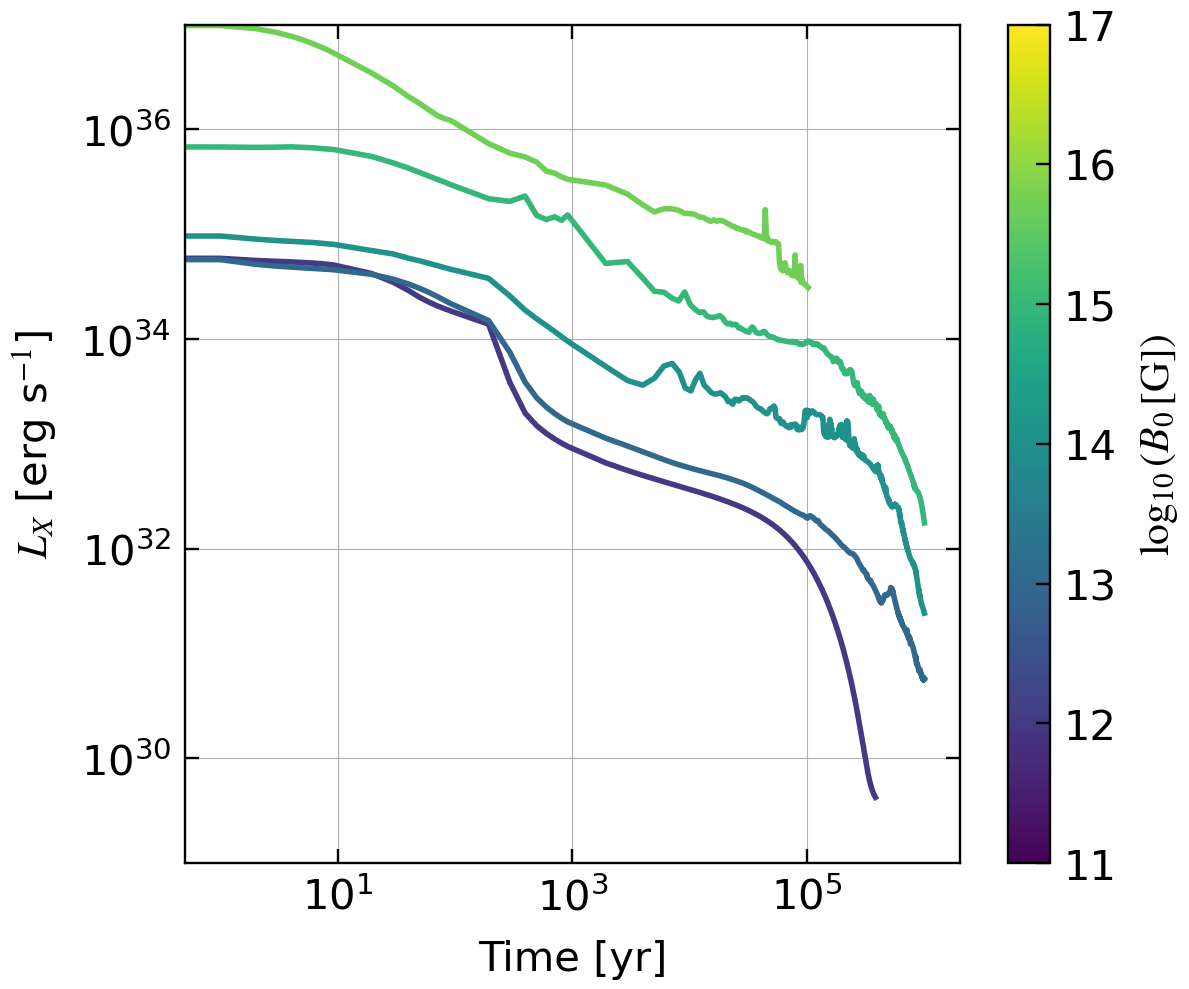

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1.0e29, 1.0e37)
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

ax.plot(
    t12,
    L12,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[0])),
    rasterized=True,
)
ax.plot(
    t13,
    L13,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[1])),
    rasterized=True,
)
ax.plot(
    t14,
    L14,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[2])),
    rasterized=True,
)
ax.plot(
    t15,
    L15,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[3])),
    rasterized=True,
)
ax.plot(
    t5e15,
    L5e15,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[4])),
    rasterized=True,
)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()

(100,)


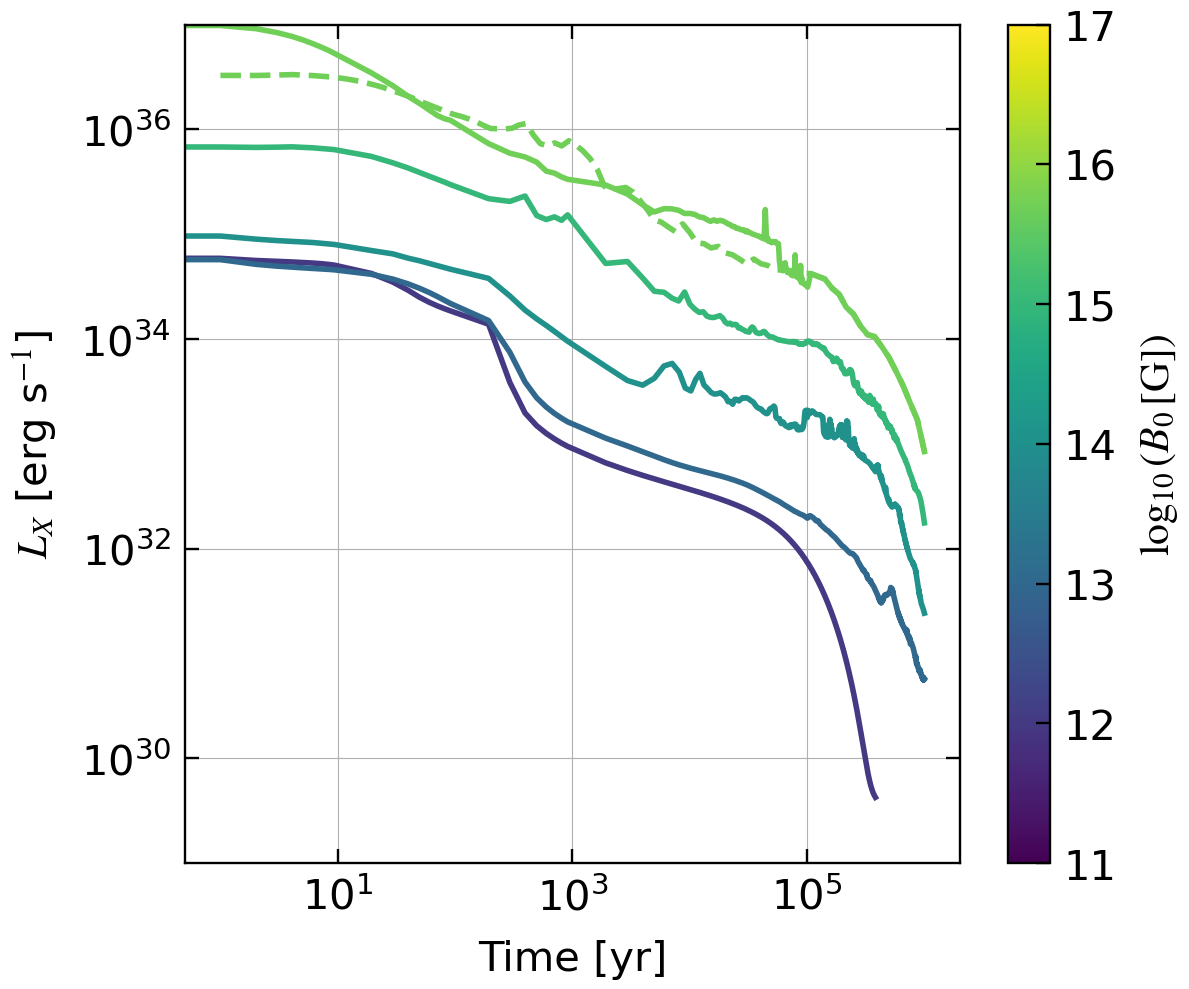

In [11]:
if (cfg["magneto-thermal_model"] == "BKS24_multi_heavy" or cfg["magneto-thermal_model"] == "BKS24_multi_light"):
    time_grid = np.logspace(0.0, 6.0, 100)

    L13_interpolator = interpolate.InterpolatedUnivariateSpline(
        t13, L13, k=1
    )
    L14_interpolator = interpolate.InterpolatedUnivariateSpline(
        t14, L14, k=1
    )
    L15_interpolator = interpolate.InterpolatedUnivariateSpline(
        t15, L15, k=1
    )
    
    L13_interp = L13_interpolator(time_grid)
    L14_interp = L14_interpolator(time_grid)
    L15_interp = L15_interpolator(time_grid)

    # Create a grid of initial magnetic fields and stack together all the cooling curves.
    L_t_stack = np.vstack(
        (L13_interp, L14_interp, L15_interp)
    ).T
    
    # Define the minimum and maximum age in [yr] and the minimum and maximum initial magnetic field in [G].
    time_range = np.array([0.0, 1.0e6])
    B0_range = np.array([1.0e12, 1.0e16])
    
    Lx_interpolator = interpolate.RectBivariateSpline(
        time_grid,
        np.array([1.e13, 1.e14, 1.e15]),
        L_t_stack,
        bbox=[time_range[0], time_range[1], B0_range[0], B0_range[1]],
        kx=1,
        ky=1,
    )

    L5e15_interp = np.squeeze(Lx_interpolator(time_grid, 5.e15))
    print(np.shape(L5e15_interp))
    
    L5e15 = np.concatenate((L5e15[t5e15 < t5e15[-1]], L5e15_interp[time_grid >= t5e15[-1]]))
    t5e15 = np.concatenate((t5e15[t5e15 < t5e15[-1]], time_grid[time_grid > t5e15[-1]]))

    fig, ax = plt.subplots(figsize=(12, 10))

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1.0e29, 1.0e37)
    ax.set_xlabel(r"Time [yr]")
    ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")
    
    ax.plot(
        t12,
        L12,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B0[0])),
        rasterized=True,
    )
    ax.plot(
        t13,
        L13,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B0[1])),
        rasterized=True,
    )
    ax.plot(
        t14,
        L14,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B0[2])),
        rasterized=True,
    )
    ax.plot(
        t15,
        L15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B0[3])),
        rasterized=True,
    )
    ax.plot(
        t5e15,
        L5e15,
        linestyle="-",
        linewidth=4,
        color=cmap(norm(log_B0[4])),
        rasterized=True,
    )
    ax.plot(
        time_grid,
        L5e15_interp,
        linestyle="--",
        linewidth=4,
        color=cmap(norm(log_B0[4])),
        rasterized=True,
    )
    
    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")
    
    plt.grid()

To perform population synthesis simulations at late times, we need to extend the luminosity after $10^6$ yr by considering the cooling during the photon dominated era.
We assume that the surface temperature of the envelope, $T_{\rm e}$, is linked to the temperature at the bottom of the envelope, $T_{\rm b}$, at the interface with the crust via the relation $T_{\rm e} \sim T_{\rm b}^{0.5 + \alpha}$, where $\alpha \sim 0.05$ (see Eq. 34 in [Page et al. 2004](https://ui.adsabs.harvard.edu/abs/2004ApJS..155..623P/abstract)).
During the photon cooling era, we have that $T_{\rm e} \propto t^{-\frac{1}{8\alpha}}$ (see Eq. 42) which translates into a luminosity evolution $L_{\gamma} \propto T_{\rm e}^4 \propto t^{-\frac{1}{2\alpha}} = t^{-10}$ (see Eq. 38). 

In [12]:
t_late = np.logspace(5, 7, 100)

index = -10.0

L12_late = L12[-1] * (t_late / t12[-1]) ** index
L13_late = L13[-1] * (t_late / t13[-1]) ** index
L14_late = L14[-1] * (t_late / t14[-1]) ** index
L15_late = L15[-1] * (t_late / t15[-1]) ** index
L5e15_late = L5e15[-1] * (t_late / t5e15[-1]) ** index

print(t12[-1])

L12_late = L12_late[t_late > t12[-1]]
L13_late = L13_late[t_late > t13[-1]]
L14_late = L14_late[t_late > t14[-1]]
L15_late = L15_late[t_late > t15[-1]]
L5e15_late = L5e15_late[t_late > t5e15[-1]]

t12_late = t_late[t_late > t12[-1]]
t13_late = t_late[t_late > t13[-1]]
t14_late = t_late[t_late > t14[-1]]
t15_late = t_late[t_late > t15[-1]]
t5e15_late = t_late[t_late > t5e15[-1]]

382215.537


In [13]:
# Concatenate the two steps of the evolution.
t12_full = np.concatenate((t12, t12_late))
t13_full = np.concatenate((t13, t13_late))
t14_full = np.concatenate((t14, t14_late))
t15_full = np.concatenate((t15, t15_late))
t5e15_full = np.concatenate((t5e15, t5e15_late))

L12_full = np.concatenate((L12, L12_late))
L13_full = np.concatenate((L13, L13_late))
L14_full = np.concatenate((L14, L14_late))
L15_full = np.concatenate((L15, L15_late))
L5e15_full = np.concatenate((L5e15, L5e15_late))

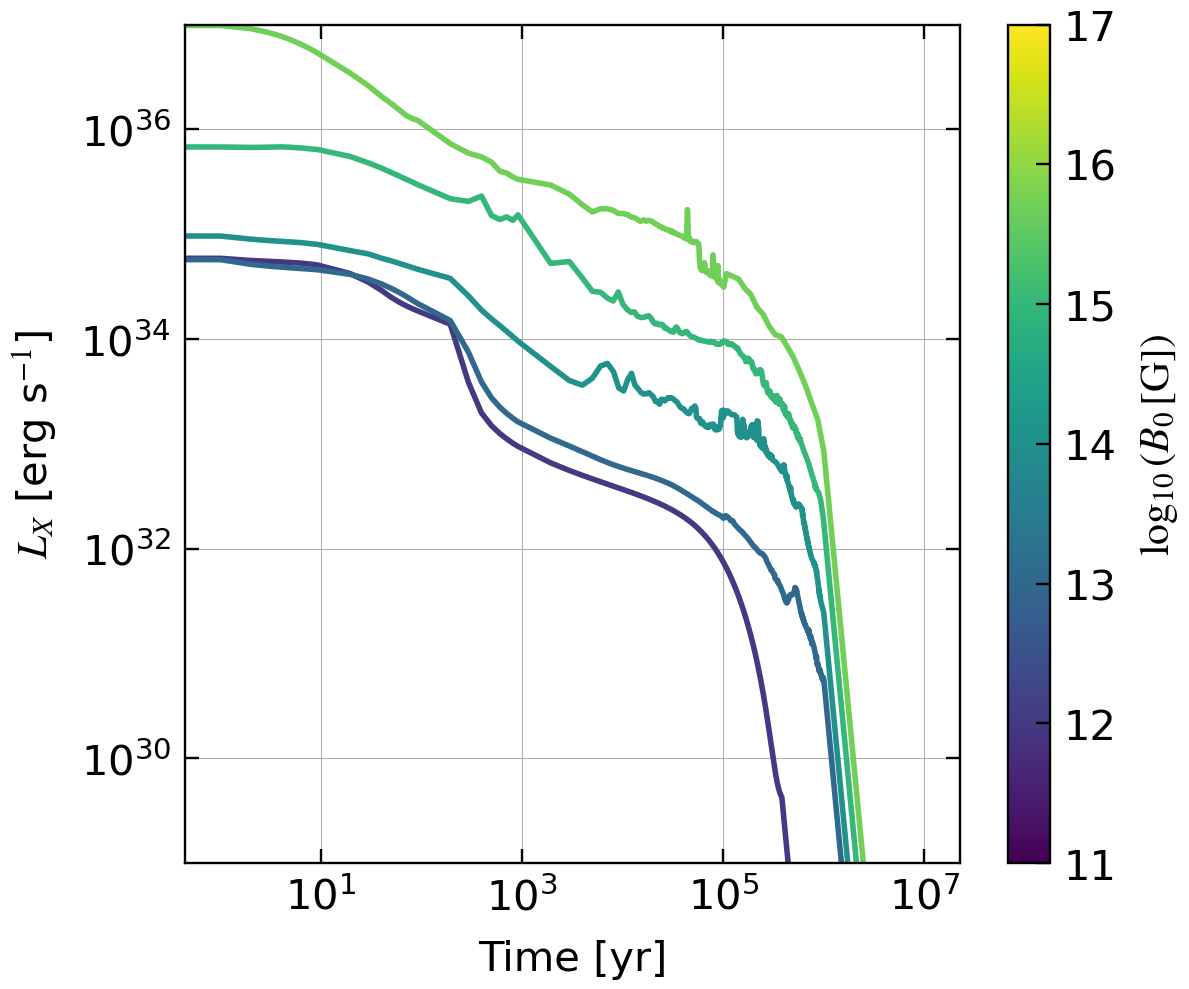

In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1.0e29, 1.0e37)
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

ax.plot(
    t12_full,
    L12_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[0])),
    rasterized=True,
)
ax.plot(
    t13_full,
    L13_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[1])),
    rasterized=True,
)
ax.plot(
    t14_full,
    L14_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[2])),
    rasterized=True,
)
ax.plot(
    t15_full,
    L15_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[3])),
    rasterized=True,
)
ax.plot(
    t5e15_full,
    L5e15_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[4])),
    rasterized=True,
)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()

NOTE: In the first hundreds to thousands of years cooling is meanly dominated by neutrinos emission produced in Urca processes in the neutron star interior (where neutrons transforms into protons and vice versa) when the star is still very hot. These neutrinos are free to escape the star end carry away a lot of energy producing a fast drop in the luminosity. After that, cooling mainly proceeds by the emission of photons from the surface. This is more visible in low-magnetic field stars as their field dissipation in the crust is not very effective in keeping the star hot. Indeed, for those stars the temperature drops as if they were not magnetized and the cooling curves are very similar. For high magnetic fields, however, the fast drop at the beginning due to neutrino emission is somewhat masked by the fact that the field dissipates and heats up the neutron star crust keeping the temperature higher for a longer time.

## Construct the interpolator function

As the length of the various cooling curves is different, let's first interpolate them using a univariate spline on the same time grid in [yr]. This is also useful to smooth them out.
In the plot, the interpolated curves are shown with dashed lines.

In [15]:
time_grid = np.logspace(0.0, 7.0, 50)

L12_interpolator = interpolate.InterpolatedUnivariateSpline(
    t12_full, L12_full, k=1
)
L13_interpolator = interpolate.InterpolatedUnivariateSpline(
    t13_full, L13_full, k=1
)
L14_interpolator = interpolate.InterpolatedUnivariateSpline(
    t14_full, L14_full, k=1
)
L15_interpolator = interpolate.InterpolatedUnivariateSpline(
    t15_full, L15_full, k=1
)
L5e15_interpolator = interpolate.InterpolatedUnivariateSpline(
    t5e15_full, L5e15_full, k=1
)

L12_interp = L12_interpolator(time_grid)
L13_interp = L13_interpolator(time_grid)
L14_interp = L14_interpolator(time_grid)
L15_interp = L15_interpolator(time_grid)
L5e15_interp = L5e15_interpolator(time_grid)

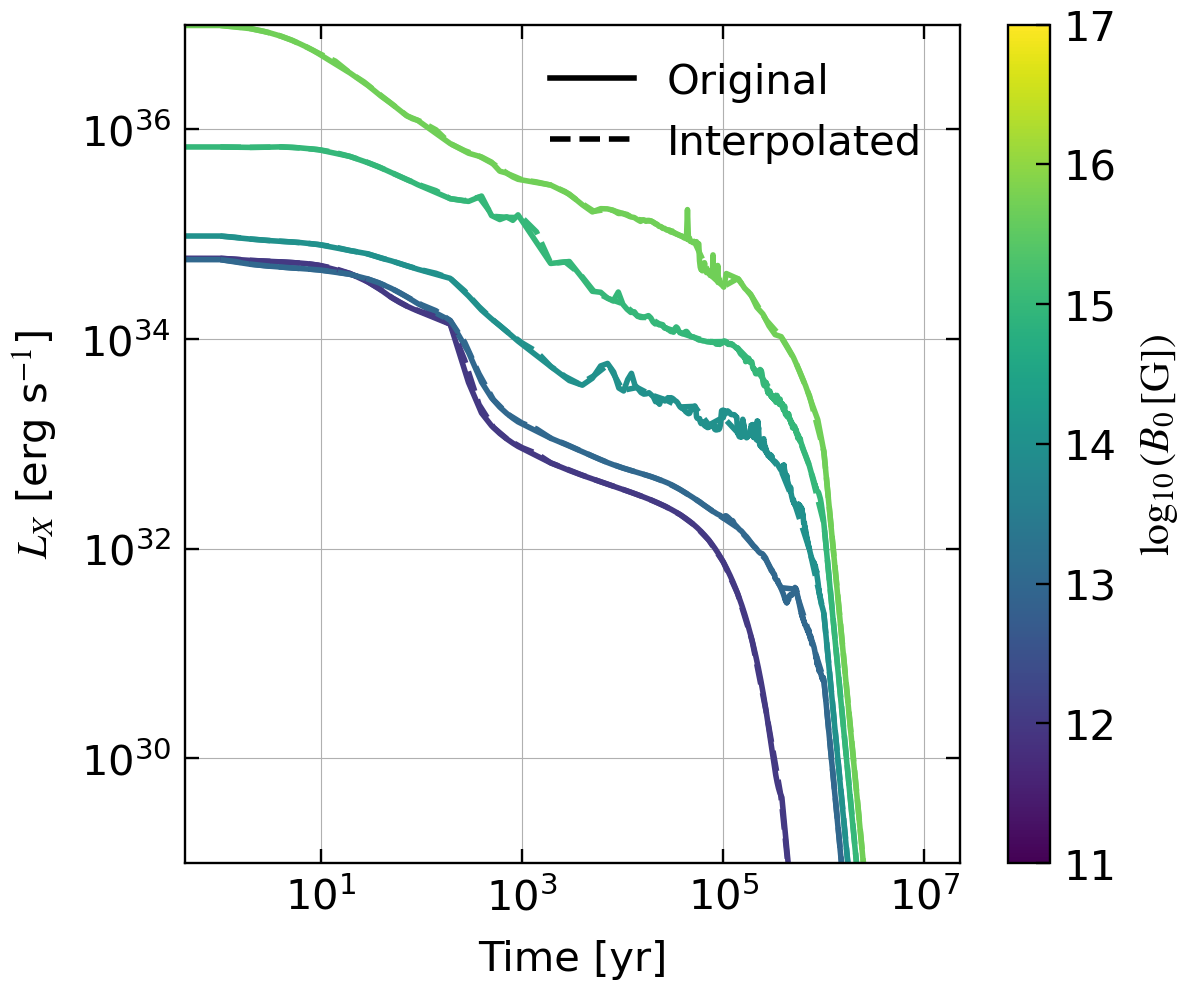

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1.0e29, 1.0e37)
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

ax.plot(
    t12_full,
    L12_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[0])),
    rasterized=True,
)
ax.plot(
    t13_full,
    L13_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[1])),
    rasterized=True,
)
ax.plot(
    t14_full,
    L14_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[2])),
    rasterized=True,
)
ax.plot(
    t15_full,
    L15_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[3])),
    rasterized=True,
)
ax.plot(
    t5e15_full,
    L5e15_full,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[4])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L12_interp,
    linestyle="--",
    linewidth=4,
    color=cmap(norm(log_B0[0])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L13_interp,
    linestyle="--",
    linewidth=4,
    color=cmap(norm(log_B0[1])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L14_interp,
    linestyle="--",
    linewidth=4,
    color=cmap(norm(log_B0[2])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L15_interp,
    linestyle="--",
    linewidth=4,
    color=cmap(norm(log_B0[3])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L5e15_interp,
    linestyle="--",
    linewidth=4,
    color=cmap(norm(log_B0[4])),
    rasterized=True,
)

# Create a legend for the line styles.
style_handles = [
    Line2D(
        [0], [0], color="black", linestyle="-", linewidth=4, label="Original"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=4,
        label="Interpolated",
    ),
]
plt.legend(handles=style_handles, frameon=False, loc=0)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()

In [17]:
# Create a grid of initial magnetic fields and stack together all the cooling curves.
B0 = 10**log_B0
L_t_stack = np.vstack(
    (L12_interp, L13_interp, L14_interp, L15_interp, L5e15_interp)
).T

# Define the minimum and maximum age in [yr] and the minimum and maximum initial magnetic field in [G].
time_range = np.array([0.0, 1.0e7])
B0_range = np.array([1.0e11, 1.0e17])

Lx_interpolator = interpolate.RectBivariateSpline(
    time_grid,
    B0,
    L_t_stack,
    bbox=[time_range[0], time_range[1], B0_range[0], B0_range[1]],
    kx=1,
    ky=1,
)

In [18]:
if cfg["magneto-thermal_model"] == "SLy4_dip-tor_heavy":
    interpolator_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/SLy4_dip-tor_heavy-envelope/interpolator_Lx.pkl"

elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_heavy":
    interpolator_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_heavy-envelope/interpolator_Lx.pkl"

elif cfg["magneto-thermal_model"] == "BKS24_dip-tor_light":
    interpolator_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_dip-tor_light-envelope/interpolator_Lx.pkl"

elif cfg["magneto-thermal_model"] == "BKS24_multi_heavy":
    interpolator_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_heavy-envelope/interpolator_Lx.pkl"

elif cfg["magneto-thermal_model"] == "BKS24_multi_light":
    interpolator_path = "../../pypopsyn/simulator/magneto_rotational_physics/magneto-thermal_evol_curves/BKS24_multi_light-envelope/interpolator_Lx.pkl"


In [19]:
# Save the interpolator function and try to import it again to see if it works.
with open(
    interpolator_path,
    "wb",
) as f:
    pickle.dump(Lx_interpolator, f)

with open(
    interpolator_path,
    "rb",
) as f:
    Lx_interpolator_import = pickle.load(f)

In [20]:
# Define a grid of times and initial magnetic fields at which we evaluate the interpolated cooling curves.
t_eval = np.logspace(0.0, 7.0, 500)
B0_eval = 10**log_B0_eval

Lt_interp = Lx_interpolator_import(t_eval, B0_eval)
print(Lt_interp.shape)

(500, 30)


Plot the resulting interpolation for a range of values.

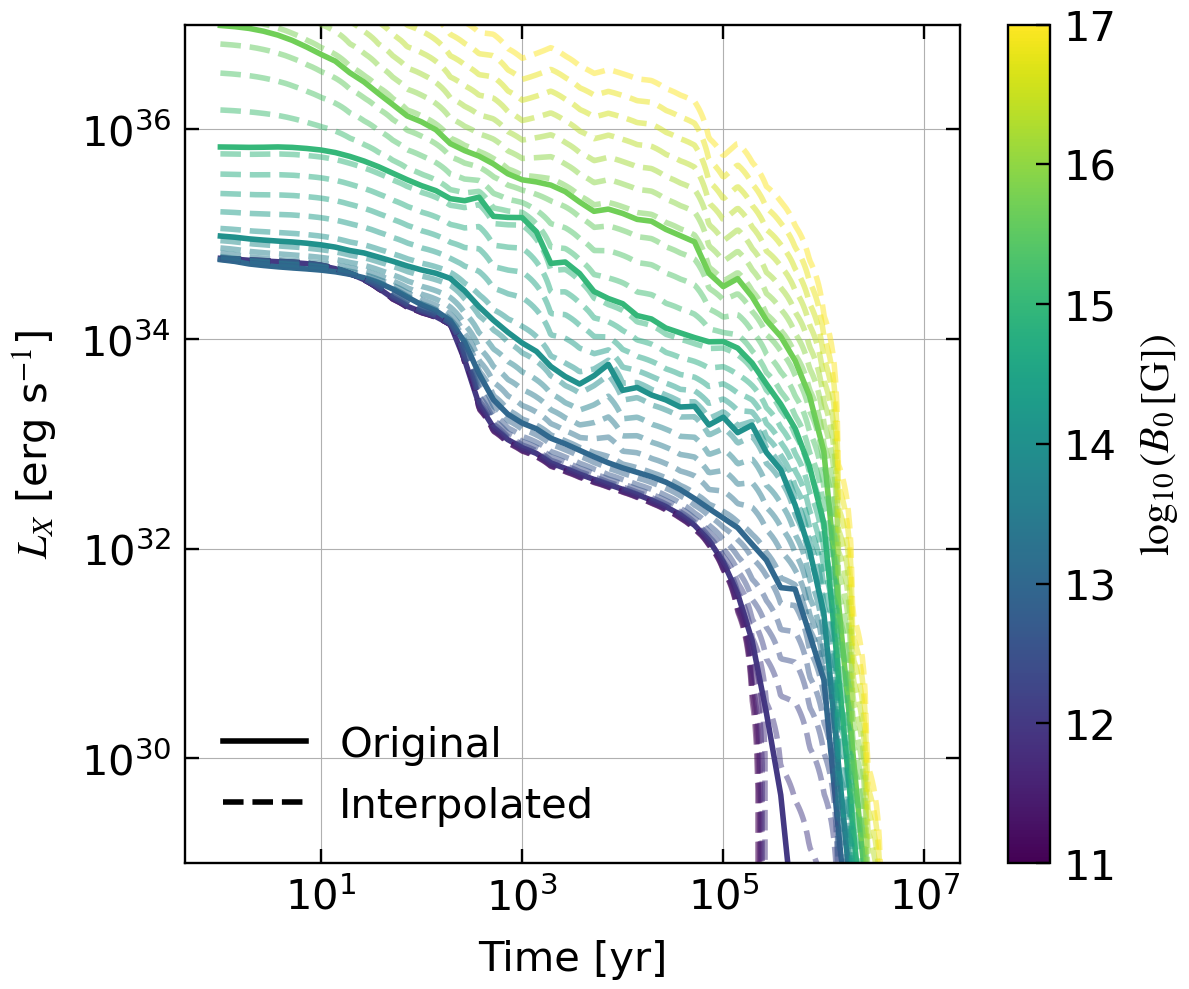

In [21]:
fig, ax = plt.subplots(figsize=(12, 10))

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1.0e29, 1.0e37)
ax.set_xlabel(r"Time [yr]")
ax.set_ylabel(r"$L_{X}$ [erg s$^{-1}$]")

ax.plot(
    time_grid,
    L12_interp,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[0])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L13_interp,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[1])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L14_interp,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[2])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L15_interp,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[3])),
    rasterized=True,
)
ax.plot(
    time_grid,
    L5e15_interp,
    linestyle="-",
    linewidth=4,
    color=cmap(norm(log_B0[4])),
    rasterized=True,
)

for i in range(len(B0_eval)):
    ax.plot(
        t_eval,
        Lt_interp[:, i],
        linestyle="--",
        linewidth=4,
        color=cmap(norm(log_B0_eval[i])),
        rasterized=True,
        alpha=0.5,
    )

# Create a legend for the line styles.
style_handles = [
    Line2D(
        [0], [0], color="black", linestyle="-", linewidth=4, label="Original"
    ),
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="--",
        linewidth=4,
        label="Interpolated",
    ),
]
plt.legend(handles=style_handles, frameon=False, loc=0)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label(r"$\log_{10}(B_0 \, {\rm[G]})$")

plt.grid()

In [22]:
# Try to evaluate the X-ray luminosity for a set of random values of the age and the initial magnetic field.
t_eval_test = np.array([1.0e3, 1.0e2])
B0_eval_test = np.logspace(13.0, 15, 2)

Lt_interp_test = Lx_interpolator_import.ev(t_eval_test, B0_eval_test)
print(Lt_interp_test)

[1.57801555e+33 2.90201663e+35]
